Лабораторна робота 2  
"Пошук асоціативних правил"  
Стецюк Максим КН-42  

Мета роботи: Ознайомитися з принципами побудови асоціативних правил (association rule mining) на реальних даних користувацьких уподобань. Навчитись виконувати пошук частих наборів елементів (frequent itemsets) і формувати асоціативні правила за допомогою метрик support, confidence і lift на основі набору даних MovieLens Small. Розвинути навички попередньої обробки даних, перетворення даних у транзакційний формат і інтерпретації результатів.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from mlxtend.frequent_patterns import apriori, association_rules

In [2]:
ratings = pd.read_csv("ml-latest-small/ratings.csv")
movies = pd.read_csv("ml-latest-small/movies.csv")
df = ratings.merge(movies, on="movieId", how="left")
liked = df[df["rating"] >= 4.0].copy()
print("Розмір з рейтингом >= 4.0:", liked.shape)
print("Кількість унік. користувачів:", liked["userId"].nunique())
print("Кількість унік. фільмів:", liked["movieId"].nunique())
liked.head()

Розмір з рейтингом >= 4.0: (48580, 6)
Кількість унік. користувачів: 609
Кількість унік. фільмів: 6298


,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


На цьому етапі ми об'єднали таблиці ratings.csv і movies.csv за movieId і залишили лише ті оцінки, де рейтинг >= 4.0  
Такі оцінки будемо трактувати як фільми, що сподобались користувачам

In [3]:
movie_support_counts = liked.groupby("title")["userId"].nunique().sort_values(ascending=False)
transaction_df = (
    liked.assign(value=1)
    .pivot_table(index="userId", columns="title", values="value", aggfunc="max", fill_value=0)
    .astype(bool)
)
transaction_df.head()

title,'71 (2014),'Hellboy': The Seeds of Creation (2004),'Salem's Lot (2004),'Til There Was You (1997),"'burbs, The (1989)",(500) Days of Summer (2009),*batteries not included (1987),...And Justice for All (1979),00 Schneider - Jagd auf Nihil Baxter (1994),1-900 (06) (1994),...,Zombieland (2009),Zookeeper (2011),Zoolander (2001),Zootopia (2016),Zulu (1964),[REC] (2007),[REC]² (2009),eXistenZ (1999),xXx (2002),¡Three Amigos! (1986)
userId,,,,,,,,,,,,,,,,,,,,,
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
5,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


Тут ми перетворили дані у транзакційний формат, де рядки це користувачі,а стовпці назви фільмів, T/F показує чи сподобався фільм конкретному користувачу.

In [4]:
freq_sets = apriori(transaction_df.astype(bool),min_support=0.05,use_colnames=True)
freq_sets["length"] = freq_sets["itemsets"].apply(len)
print("Популярні фільми:")
freq_sets.sort_values(by="support", ascending=False).head(10)

Популярні фільми:


,support,itemsets,length
267,0.449918,"frozenset({Shawshank Redemption, The (1994)})",1
119,0.408867,frozenset({Forrest Gump (1994)}),1
244,0.400657,frozenset({Pulp Fiction (1994)}),1
273,0.369458,"frozenset({Silence of the Lambs, The (1991)})",1
206,0.364532,"frozenset({Matrix, The (1999)})",1
299,0.330049,frozenset({Star Wars: Episode IV - A New Hope ...,1
115,0.293924,frozenset({Fight Club (1999)}),1
260,0.287356,frozenset({Schindler's List (1993)}),1
2228,0.275862,"frozenset({Forrest Gump (1994), Shawshank Rede...",2
300,0.275862,frozenset({Star Wars: Episode V - The Empire S...,1


Застосували Apriori для пошуку частих наборів фільмів при min_support 0.05. В результати виведено 10 найпопулярніших наборів.
Отримані значення показують, які фільми найчастіше зустрічаються у вподобаннях користувачів, а також дозволяють виявити як окремі популярні фільми, так і їх комбінації.

In [5]:
rules = association_rules(
    freq_sets,
    metric="confidence",
    min_threshold=0.3
)
top_rules = rules.sort_values(by='lift', ascending=False).head(10)
top_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']]

,antecedents,consequents,support,confidence,lift
345902,frozenset({Star Wars: Episode VI - Return of t...,frozenset({Star Wars: Episode V - The Empire S...,0.052545,0.888889,13.203252
345914,frozenset({Star Wars: Episode V - The Empire S...,frozenset({Star Wars: Episode VI - Return of t...,0.052545,0.780488,13.203252
345894,frozenset({Star Wars: Episode V - The Empire S...,frozenset({Star Wars: Episode VI - Return of t...,0.052545,0.864865,12.846407
345895,frozenset({Star Wars: Episode V - The Empire S...,frozenset({Star Wars: Episode VI - Return of t...,0.052545,0.864865,12.846407
345920,frozenset({Star Wars: Episode VI - Return of t...,frozenset({Star Wars: Episode V - The Empire S...,0.052545,0.780488,12.846407
345919,frozenset({Star Wars: Episode VI - Return of t...,frozenset({Star Wars: Episode V - The Empire S...,0.052545,0.780488,12.846407
345923,frozenset({Star Wars: Episode V - The Empire S...,frozenset({Star Wars: Episode VI - Return of t...,0.052545,0.695652,12.837945
345888,frozenset({Star Wars: Episode VI - Return of t...,frozenset({Star Wars: Episode V - The Empire S...,0.052545,0.969697,12.837945
345912,frozenset({Star Wars: Episode IV - A New Hope ...,frozenset({Star Wars: Episode VI - Return of t...,0.052545,0.842105,12.821053
345903,frozenset({Star Wars: Episode VI - Return of t...,frozenset({Star Wars: Episode IV - A New Hope ...,0.052545,0.800000,12.821053


Побудовано асоціативні правила на основі знайдених частих наборів із використанням метрики min_confidence 0.3. Далі було виведено 10 найсильніших залежностей.
Отримані результати демонструють, які фільми найчастіше переглядаються разом, якщо користувачу подобається один фільм, з високою ймовірністю йому сподобається й інший (consequent).
Високі значення lift свідчать про наявність сильної асоціації між фільмами.

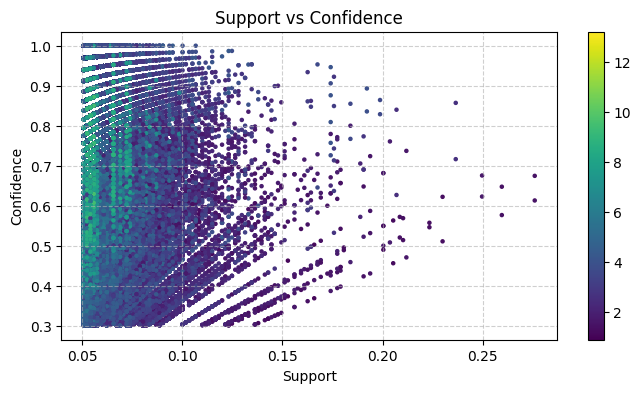

In [6]:
plt.figure(figsize=(8, 4))
plt.scatter(
    rules["support"],
    rules["confidence"],
    c=rules["lift"],
    s=5
)
plt.title("Support vs Confidence")
plt.xlabel("Support")
plt.ylabel("Confidence")
plt.grid(True, linestyle="--", alpha=0.6)
plt.colorbar()
plt.show()

На графіку видно залежність між support та confidence для побудованих асоціативних правил та колір точок відповідає значенню lift.
Більшість правил зосереджена в області невисокого support 0.05–0.1, що свідчить про те, що навіть рідкісні комбінації фільмів можуть формувати правила з високою довірою, при цьому confidence варіюється в широкому діапазоні, однак найбільш щільна концентрація спостерігається в межах 0.5–0.9. Також видно, що правила з високим значенням lift переважно відповідають нижчим значенням support, що означає сильні, але менш поширені асоціації між фільмами. Правила з більшим support мають нижчий lift, тобто є більш загальними, але менш інформативними.

У лабораторній роботі виконано пошук асоціативних правил на основі набору даних ml-small. Дані було підготовлено: таблиці об'єднано, залишено лише оцінки >= 4.0, після чого сформовано транзакційну матрицю користувач-фільм. Тоді за допомогою Apriori було знайдено часті набори фільмів і на їх основі побудовано асоціативні правила.
Результати показують, що асоціативні правила можуть використовуватися у рекомендаційних системах для виявлення фільмів, які часто подобаються одним і тим самим користувачам. Параметри min_support і min_confidence впливають на кількість знайдених правил, при збільшенні порогів кількість правил зменшується, але самі правила стають більш надійними.